In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression

In [25]:
df = pd.read_csv("loan_approval_data.csv")
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [30]:
#to handle missing value
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns
categorical_cols.size + numerical_cols.size

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
df.head()
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])
df.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


Text(0.5, 1.0, 'Is Loan Approved or not')

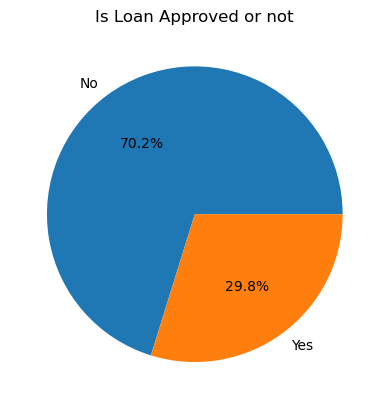

In [37]:
#eda exploratory data analysis

#how balance data are?
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels = ["No","Yes"],autopct = "%1.1f%%")
plt.title("Is Loan Approved or not")

[Text(0, 0, '621'), Text(0, 0, '379')]

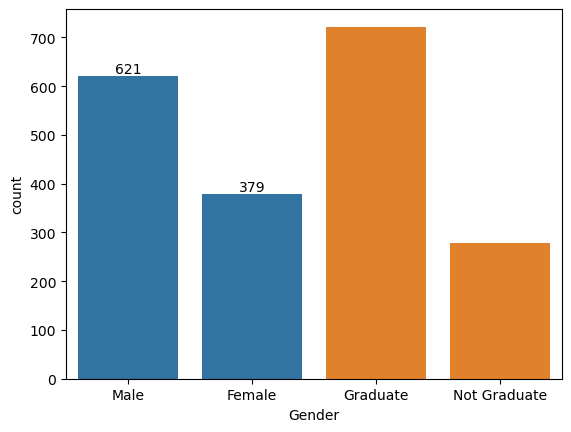

In [42]:
gender_cnt = df["Gender"].value_counts()
sns.barplot(gender_cnt)
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

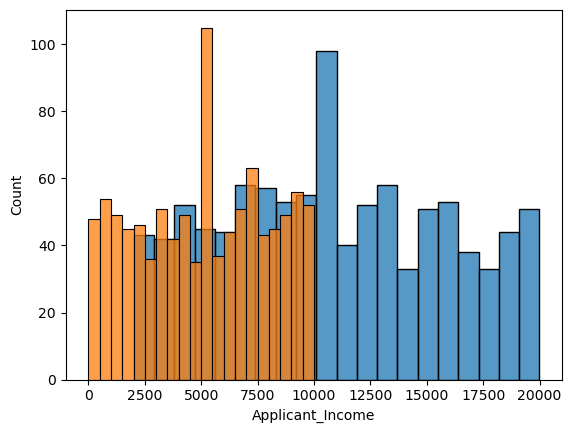

In [44]:
#based on income 
sns.histplot(
    data = df,
    x =  "Applicant_Income",
    bins= 20
)
sns.histplot(
    data = df,
    x =  "Coapplicant_Income",
    bins= 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

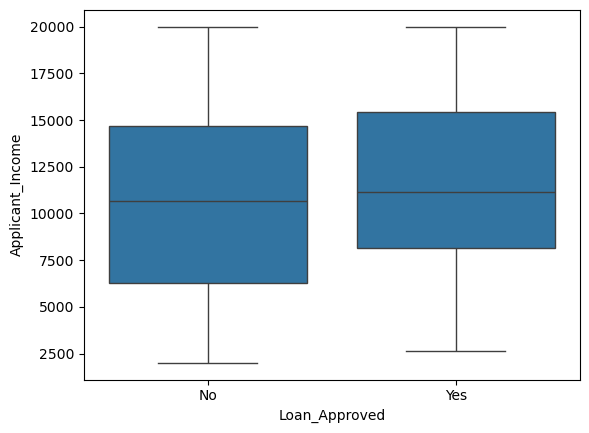

In [46]:
#ouliers-boxplot
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

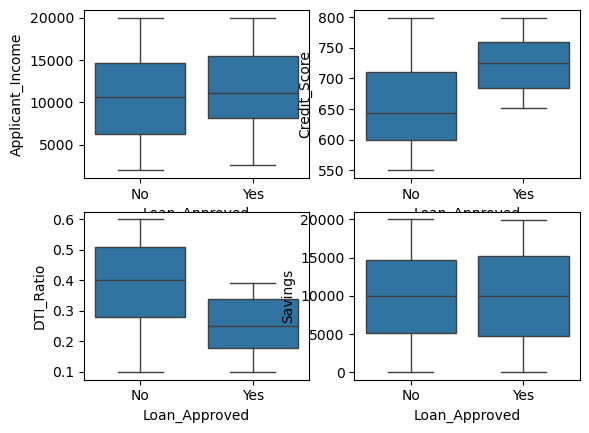

In [48]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0],data = df ,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax = axes[0,1],data = df ,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax = axes[1,0],data = df ,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax = axes[1,1],data = df ,x="Loan_Approved",y="Savings")

<Axes: xlabel='Credit_Score', ylabel='Count'>

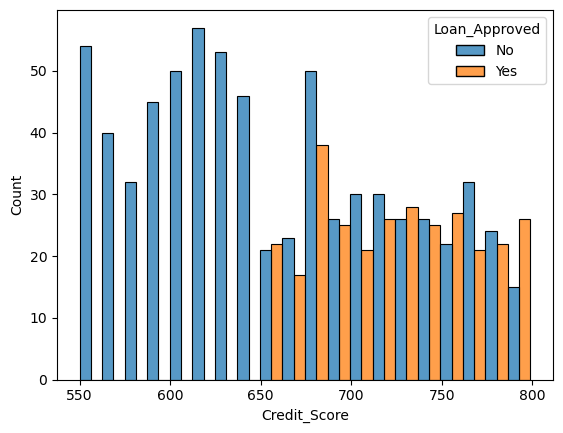

In [50]:
#credit score with loan approval
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue= "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

In [54]:
#Remove Applicant Id
df = df.drop("Applicant_ID",axis=1)

In [73]:
le = LabelEncoder()
df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"]= le.fit_transform(df["Loan_Approved"])
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop = "first",sparse_output=False,handle_unknown = "ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_features_names_out(cols),index =df.index)
df = pd.concat([df.drop(columns=cols),encoded_df],axis =1)

AttributeError: 'OneHotEncoder' object has no attribute 'get_features_names_out'

In [70]:
#Test-split-train || features scalling
X=df.drop("Loan_Approved",axis=1)
y= df["Loan_Approved"]
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_test.head()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'Salaried'

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)